In [ ]:
# >>> repo path setup (auto-added during reorg; keeps this notebook runnable from notebooks/) <<<
import os, sys
_p = os.getcwd()
while not os.path.isdir(os.path.join(_p, 'src')) and os.path.dirname(_p) != _p:
    _p = os.path.dirname(_p)
os.chdir(_p)
sys.path.insert(0, os.path.join(_p, 'src'))
# <<< end repo path setup >>>

In [1]:
%load_ext autoreload
%autoreload 2

In [ ]:
%load_ext autoreload
%autoreload 2

In [2]:
import os
import numpy as np
from tqdm import tqdm
from pathlib import Path
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation

import torch
import torch.nn.functional as F
from torch import optim
from torch.optim.lr_scheduler import ExponentialLR
from torchsummary import summary

from utils.vae import VanillaVAE
from utils.vae_utils import create_dataloaders
from utils.project_plots import plot_2d

### Load Data

In [3]:
path = Path('/net/vision/scr2/haipeng/FWI-HMC')
data = np.load(path/'model2D/sa_prior_time25_slice64_8002_samples_5m.npy')
data = np.expand_dims(data, axis=1)
print(f"Data shape: {data.shape}, min: {data.min()}, max: {data.max()}")

Data shape: (8000, 1, 15, 179), min: 0.0, max: 0.5676827511090909


In [4]:
# Resample to (64, 64) using bilinear interpolation and rescale to [0, 1]
data = F.interpolate(torch.from_numpy(data) , size=(64, 64), mode='bilinear', align_corners=False)

print(f"Data shape: {data.shape}, min: {data.min()}, max: {data.max()}")

Data shape: torch.Size([8000, 1, 64, 64]), min: 0.0, max: 0.5573965518897543


In [5]:
# select random 7500 for training, 500 for validation
np.random.seed(42)
indices = np.random.permutation(data.shape[0])
train_indices = indices[:7800]
val_indices = indices[7800:8000]

train_data = data[train_indices].clone()
val_data = data[val_indices].clone()

print(f"Train data shape: {train_data.shape}, min: {train_data.min()}, max: {train_data.max()}")
print(f"  Val data shape: {val_data.shape}, min: {val_data.min()}, max: {val_data.max()}")

# save the processed data
np.save(path/'model2D/sa_prior_time25_samples_64x64_train.npy', train_data)
np.save(path/'model2D/sa_prior_time25_samples_64x64_val.npy', val_data)

del data

Train data shape: torch.Size([7800, 1, 64, 64]), min: 0.0, max: 0.5573965518897543
  Val data shape: torch.Size([200, 1, 64, 64]), min: 0.0, max: 0.5320130807527018


In [6]:
x_sat = np.arange(train_data.shape[-1]) * 5.0
z_sat = np.arange(train_data.shape[-2]) * 5.0
extent_prior = (x_sat[0], x_sat[-1], z_sat[-1], z_sat[0])

extent_prior

(0.0, 315.0, 315.0, 0.0)

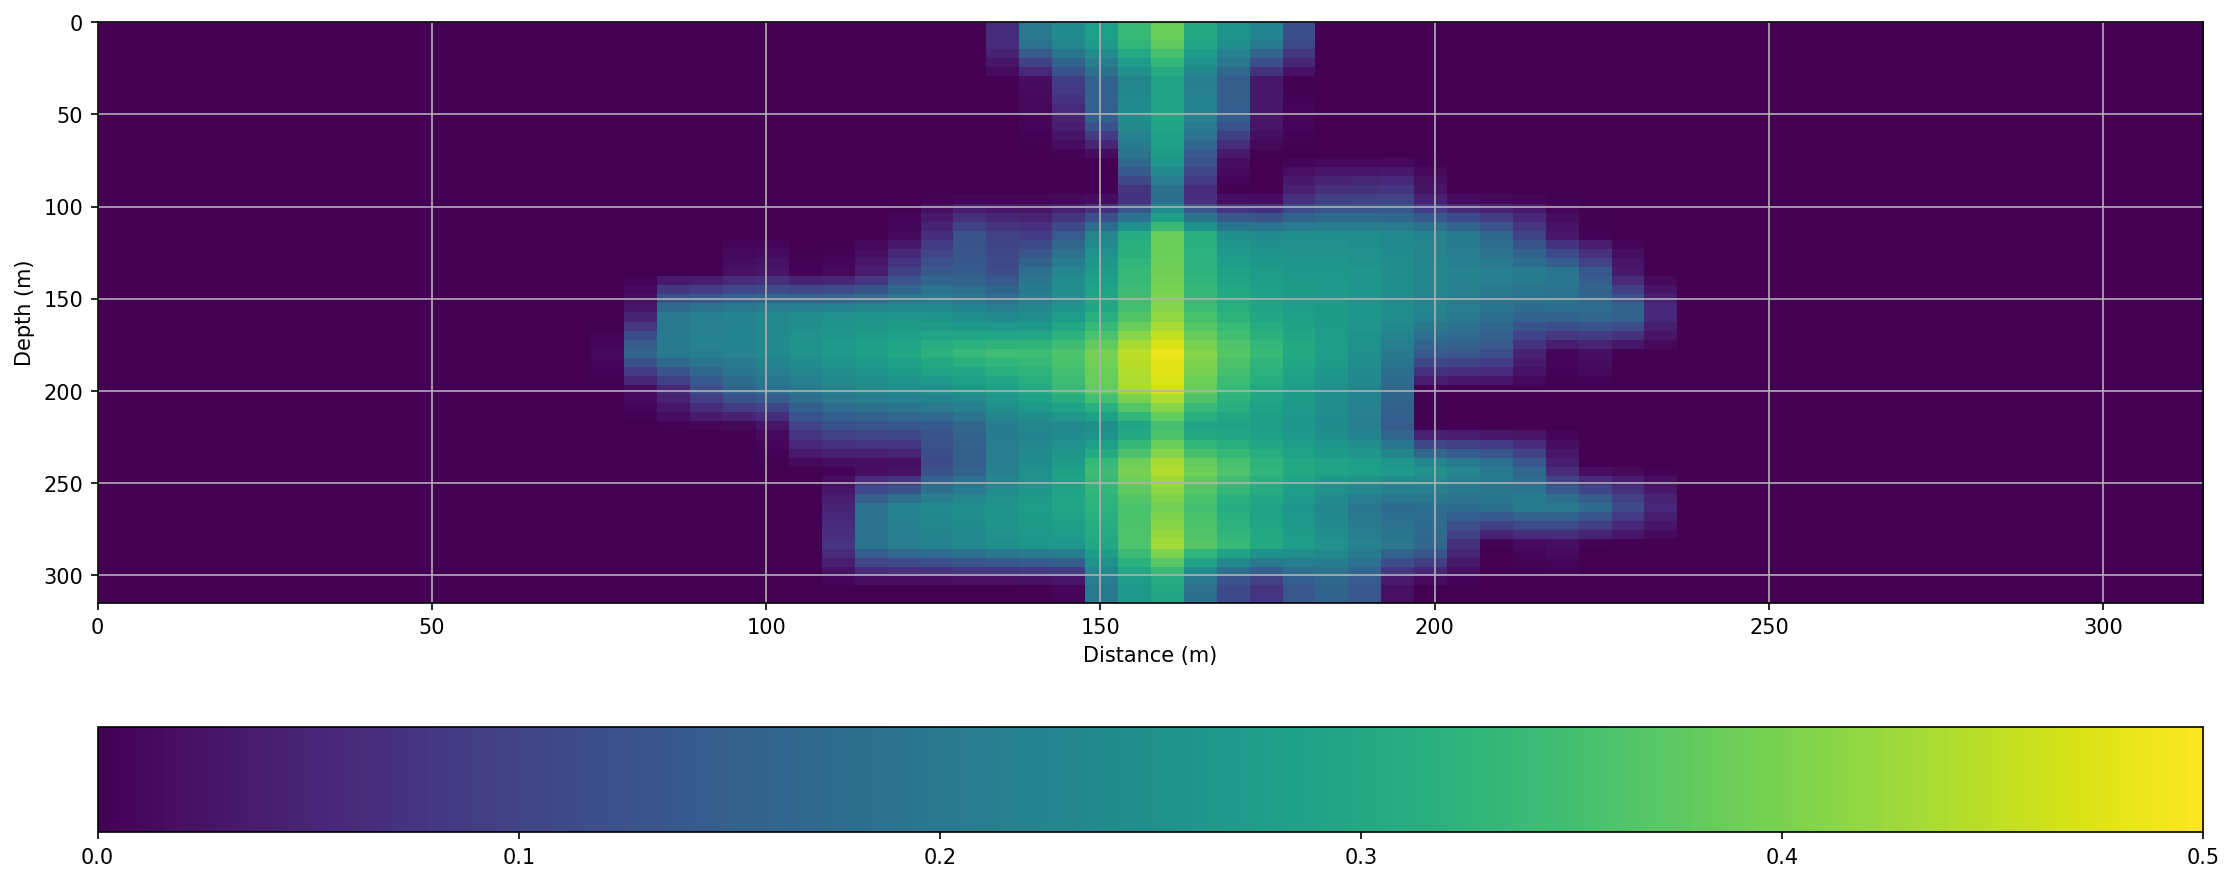

In [7]:
plot_2d(x_sat, z_sat, train_data[10].squeeze(), vmin=0, vmax=0.5, cmap='viridis')

### Parameters

In [8]:

# Data
batch_size = 256

# Model
in_channels = 1
latent_dim = 64
# latent_dim = 128

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Optimizer
learning_rate = 1e-3
weight_decay = 0.0
num_epochs = 100
scheduler_gamma = 0.95

# Loss function weights
# kld_weight = 0.00080
# kld_weight = 0.00020
# kld_weight = 0.0001
kld_weight = 0.000015

path_vae = path / 'VAE'

In [9]:
# Load data
train_loader, test_loader = create_dataloaders(train_data, batch_size=batch_size, train_ratio=0.90, shuffle=True)

# Create model
model = VanillaVAE(in_channels=in_channels, latent_dim=latent_dim).to(device)

# Optimizer and scheduler
optimizer = optim.Adam(model.parameters(), lr=learning_rate, weight_decay=weight_decay)
scheduler = ExponentialLR(optimizer, gamma=0.95)

In [10]:
summary(model, input_size=(1, 64, 64))
# model

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1           [-1, 32, 32, 32]             320
       BatchNorm2d-2           [-1, 32, 32, 32]              64
         LeakyReLU-3           [-1, 32, 32, 32]               0
            Conv2d-4           [-1, 64, 16, 16]          18,496
       BatchNorm2d-5           [-1, 64, 16, 16]             128
         LeakyReLU-6           [-1, 64, 16, 16]               0
            Conv2d-7            [-1, 128, 8, 8]          73,856
       BatchNorm2d-8            [-1, 128, 8, 8]             256
         LeakyReLU-9            [-1, 128, 8, 8]               0
           Conv2d-10            [-1, 256, 4, 4]         295,168
      BatchNorm2d-11            [-1, 256, 4, 4]             512
        LeakyReLU-12            [-1, 256, 4, 4]               0
           Conv2d-13            [-1, 512, 2, 2]       1,180,160
      BatchNorm2d-14            [-1, 51

In [11]:
train_losses = []
test_losses = []
data_losses = []
kld_losses = []

for epoch in range(num_epochs):
    model.train()
    total_train_loss = 0
    total_kld_loss = 0
    total_data_loss = 0
    train_bar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs}", leave=False)

    for batch in train_bar:
        batch = batch.to(device)

        optimizer.zero_grad()
        recons, input_, mu, log_var = model(batch)
        loss_dict = model.loss_function(recons, input_, mu, log_var, M_N=kld_weight)

        loss = loss_dict['loss']
        loss.backward()
        optimizer.step()

        total_train_loss += loss.item()
        total_data_loss  += loss_dict['Reconstruction_Loss'].item()
        total_kld_loss   += loss_dict['KLD'].item()

    # ---------- Evaluation ----------
    model.eval()
    total_test_loss = 0
    with torch.no_grad():
        for batch in test_loader:
            batch = batch.to(device)
            recons, input_, mu, log_var = model(batch)
            loss_dict = model.loss_function(recons, input_, mu, log_var, M_N=kld_weight)
            total_test_loss += loss_dict['loss'].item()

    avg_train_loss = total_train_loss / len(train_loader)
    avg_test_loss = total_test_loss / len(test_loader)
    avg_kld_loss = total_kld_loss / len(train_loader)
    avg_data_loss = total_data_loss / len(train_loader)

    train_losses.append(avg_train_loss)
    test_losses.append(avg_test_loss)
    data_losses.append(avg_data_loss)
    kld_losses.append(avg_kld_loss)
    

    tqdm.write(f"Epoch {epoch+1:02d}, LR: {scheduler.get_last_lr()[0]:.6f} | Train Loss: {avg_train_loss:.4f} | Test Loss: {avg_test_loss:.4f}")

    # Update learning rate
    scheduler.step()

train_losses = np.array(train_losses)
test_losses  = np.array(test_losses)
data_losses  = np.array(data_losses)
kld_losses   = np.array(kld_losses)

os.makedirs(path_vae, exist_ok=True)
torch.save(model.state_dict(), path_vae / f"vae_latent_dim{latent_dim}_kld_weight{kld_weight}.pth")
np.savez(path_vae / f"vae_latent_dim{latent_dim}_kld_weight{kld_weight}_losses.npz", train_losses=train_losses, test_losses=test_losses, data_losses=data_losses, kld_losses=kld_losses)

Epoch 01, LR: 0.001000 | Train Loss: 0.0377 | Test Loss: 0.0081


Epoch 02, LR: 0.000950 | Train Loss: 0.0043 | Test Loss: 0.0037


Epoch 03, LR: 0.000902 | Train Loss: 0.0033 | Test Loss: 0.0031


Epoch 04, LR: 0.000857 | Train Loss: 0.0029 | Test Loss: 0.0027


Epoch 05, LR: 0.000815 | Train Loss: 0.0026 | Test Loss: 0.0025


...

Epoch 96, LR: 0.000008 | Train Loss: 0.0015 | Test Loss: 0.0015


Epoch 97, LR: 0.000007 | Train Loss: 0.0015 | Test Loss: 0.0015


Epoch 98, LR: 0.000007 | Train Loss: 0.0015 | Test Loss: 0.0015


Epoch 99, LR: 0.000007 | Train Loss: 0.0015 | Test Loss: 0.0015


Epoch 100, LR: 0.000006 | Train Loss: 0.0015 | Test Loss: 0.0015


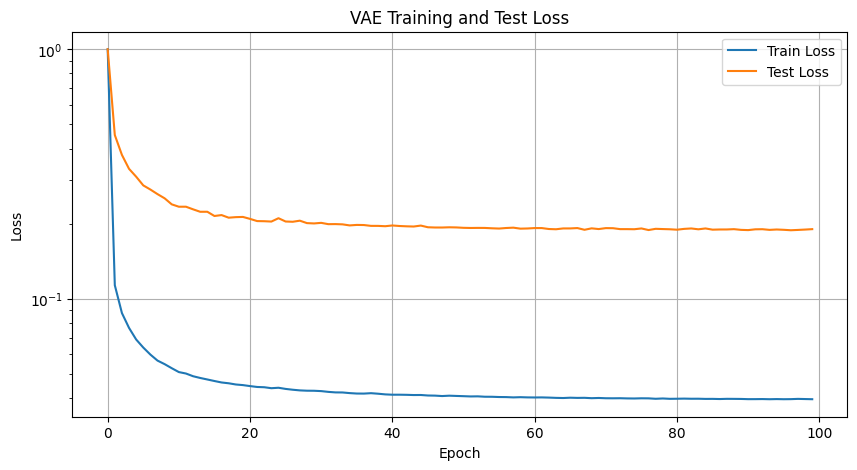

In [12]:
plt.figure(figsize=(10, 5))
plt.plot(train_losses/train_losses[0], label='Train Loss')
plt.plot(test_losses/test_losses[0], label='Test Loss')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.yscale('log')
plt.legend()
plt.grid(True)
plt.title("VAE Training and Test Loss")
plt.show()

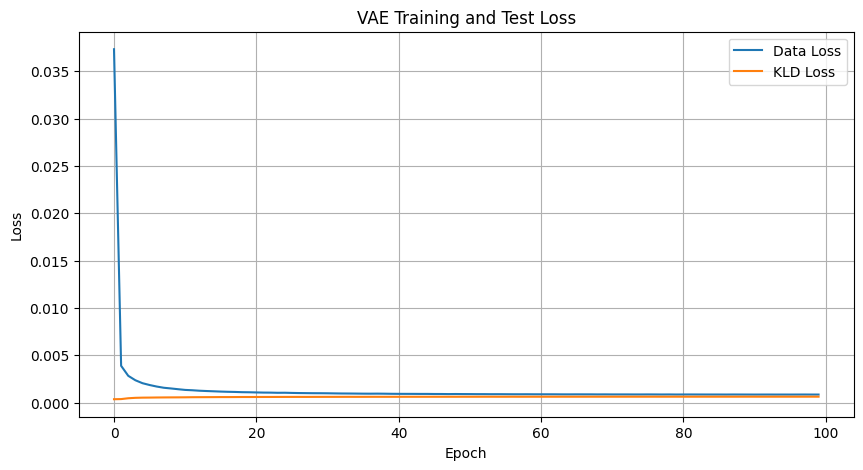

In [13]:
plt.figure(figsize=(10, 5))
plt.plot(data_losses, label='Data Loss')
plt.plot(-kld_losses * kld_weight, label='KLD Loss')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.title("VAE Training and Test Loss")
plt.show()


In [14]:
# Create an iterator
train_iter = iter(train_loader)

# Get the first batch
batch = next(train_iter)
batch = batch.to(device)

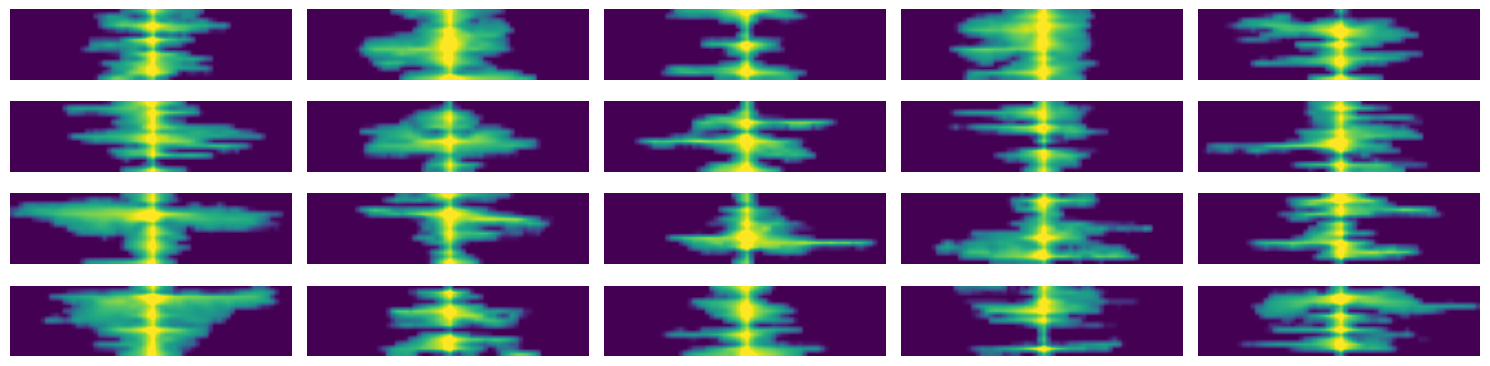

In [15]:
num_samples = 20
rows = 4
cols = num_samples // rows
fig, axes = plt.subplots(rows, cols, figsize=(cols * 3, rows * 1))

for i in range(num_samples):
    r, c = divmod(i, cols)
    ax = axes[r, c]
    ax.imshow(batch[i].cpu().numpy().squeeze(), cmap='viridis', aspect=1/4, vmin=0, vmax=0.4)
    ax.axis('off')

plt.tight_layout()
plt.show()

In [16]:
model.eval()
recons, input_, mu, log_var = model(batch)

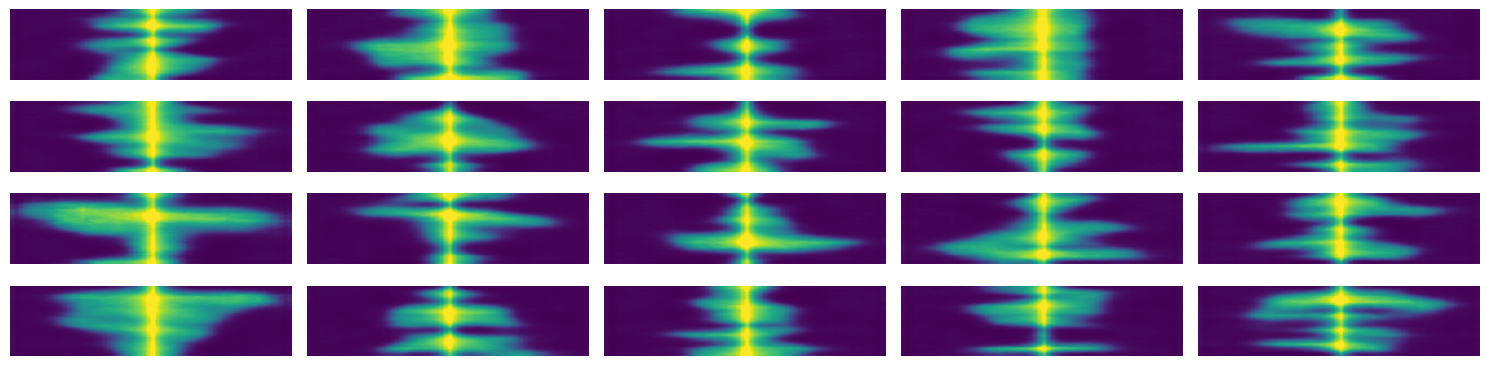

In [17]:
num_samples = 20
rows = 4
cols = num_samples // rows

fig, axes = plt.subplots(rows, cols, figsize=(cols * 3, rows * 1))

for i in range(num_samples):
    r, c = divmod(i, cols)
    ax = axes[r, c]
    ax.imshow(recons[i].detach().cpu().numpy().squeeze(), cmap='viridis', aspect=1/4, vmin=0, vmax=0.4)
    ax.axis('off')

plt.tight_layout()
plt.show()

In [18]:
model.latent_dim

64

In [19]:
model.eval()

# Sample latent vectors from standard normal
num_samples = 8000
z = torch.randn(num_samples, model.latent_dim).to(device)

# Generate images from latent vectors
with torch.no_grad():
    generated = model.decode(z)
    
print(f"Generated shape: {generated.shape}, min: {generated.min()}, max: {generated.max()}")

Generated shape: torch.Size([8000, 1, 64, 64]), min: 1.610492063264246e-06, max: 0.49486932158470154


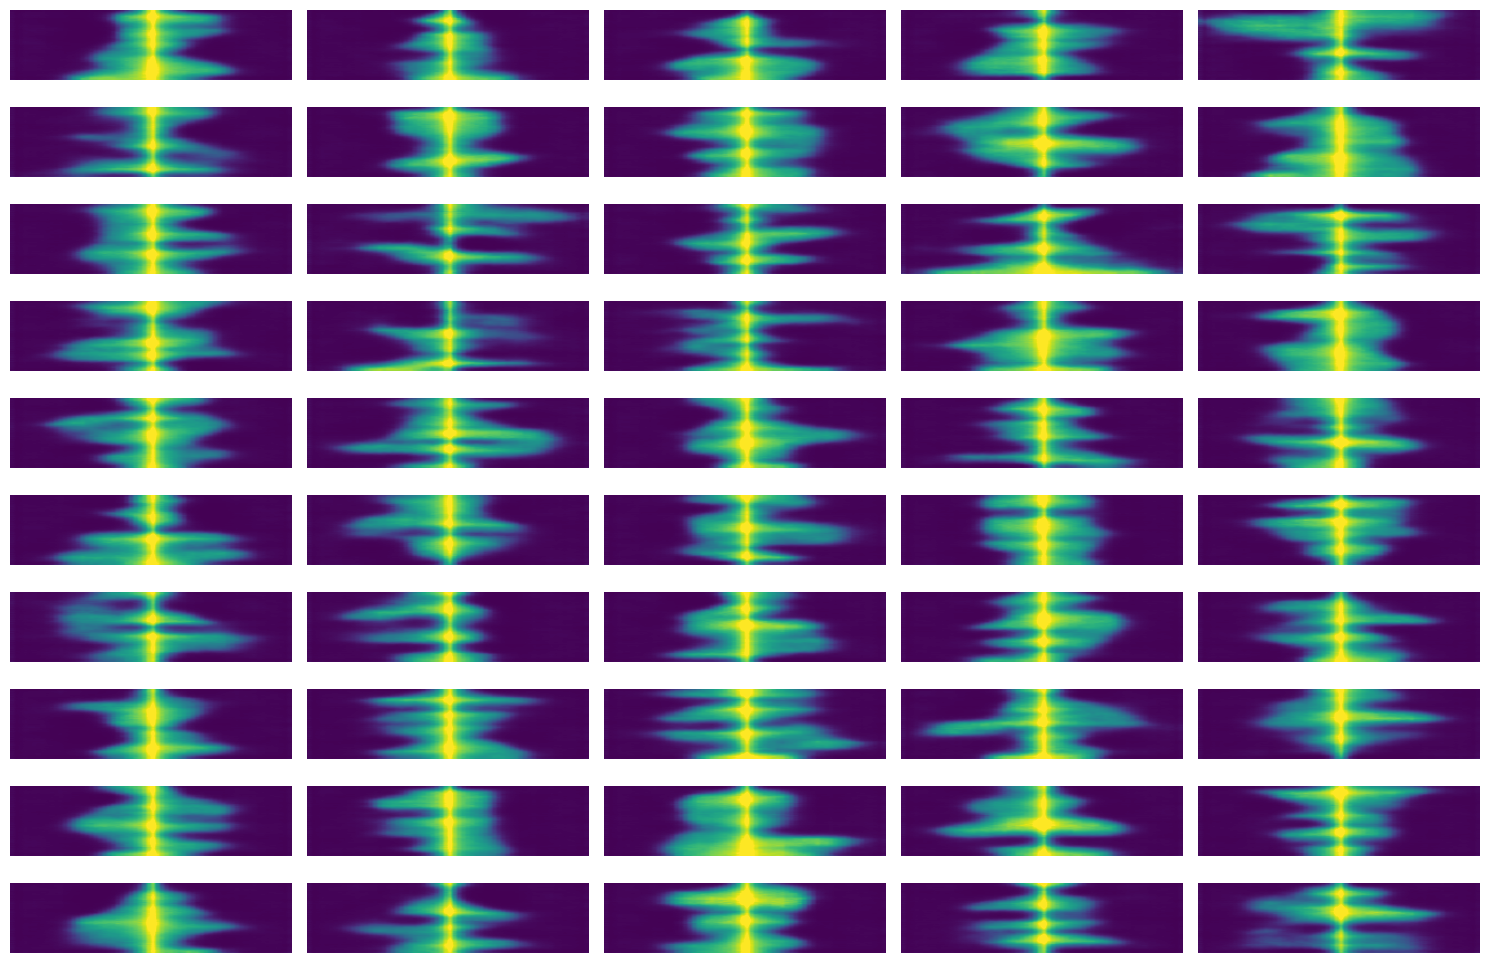

In [20]:
cols = 5
rows = 50 // cols

fig, axes = plt.subplots(rows, cols, figsize=(cols * 3, rows * 1))

for i in range(50):
    r, c = divmod(i, cols)
    ax = axes[r, c]
    ax.imshow(generated[1000+i].detach().cpu().numpy().squeeze(), cmap='viridis', aspect=1/4, vmin=0, vmax=0.4)
    ax.axis('off')
plt.tight_layout()
plt.show()

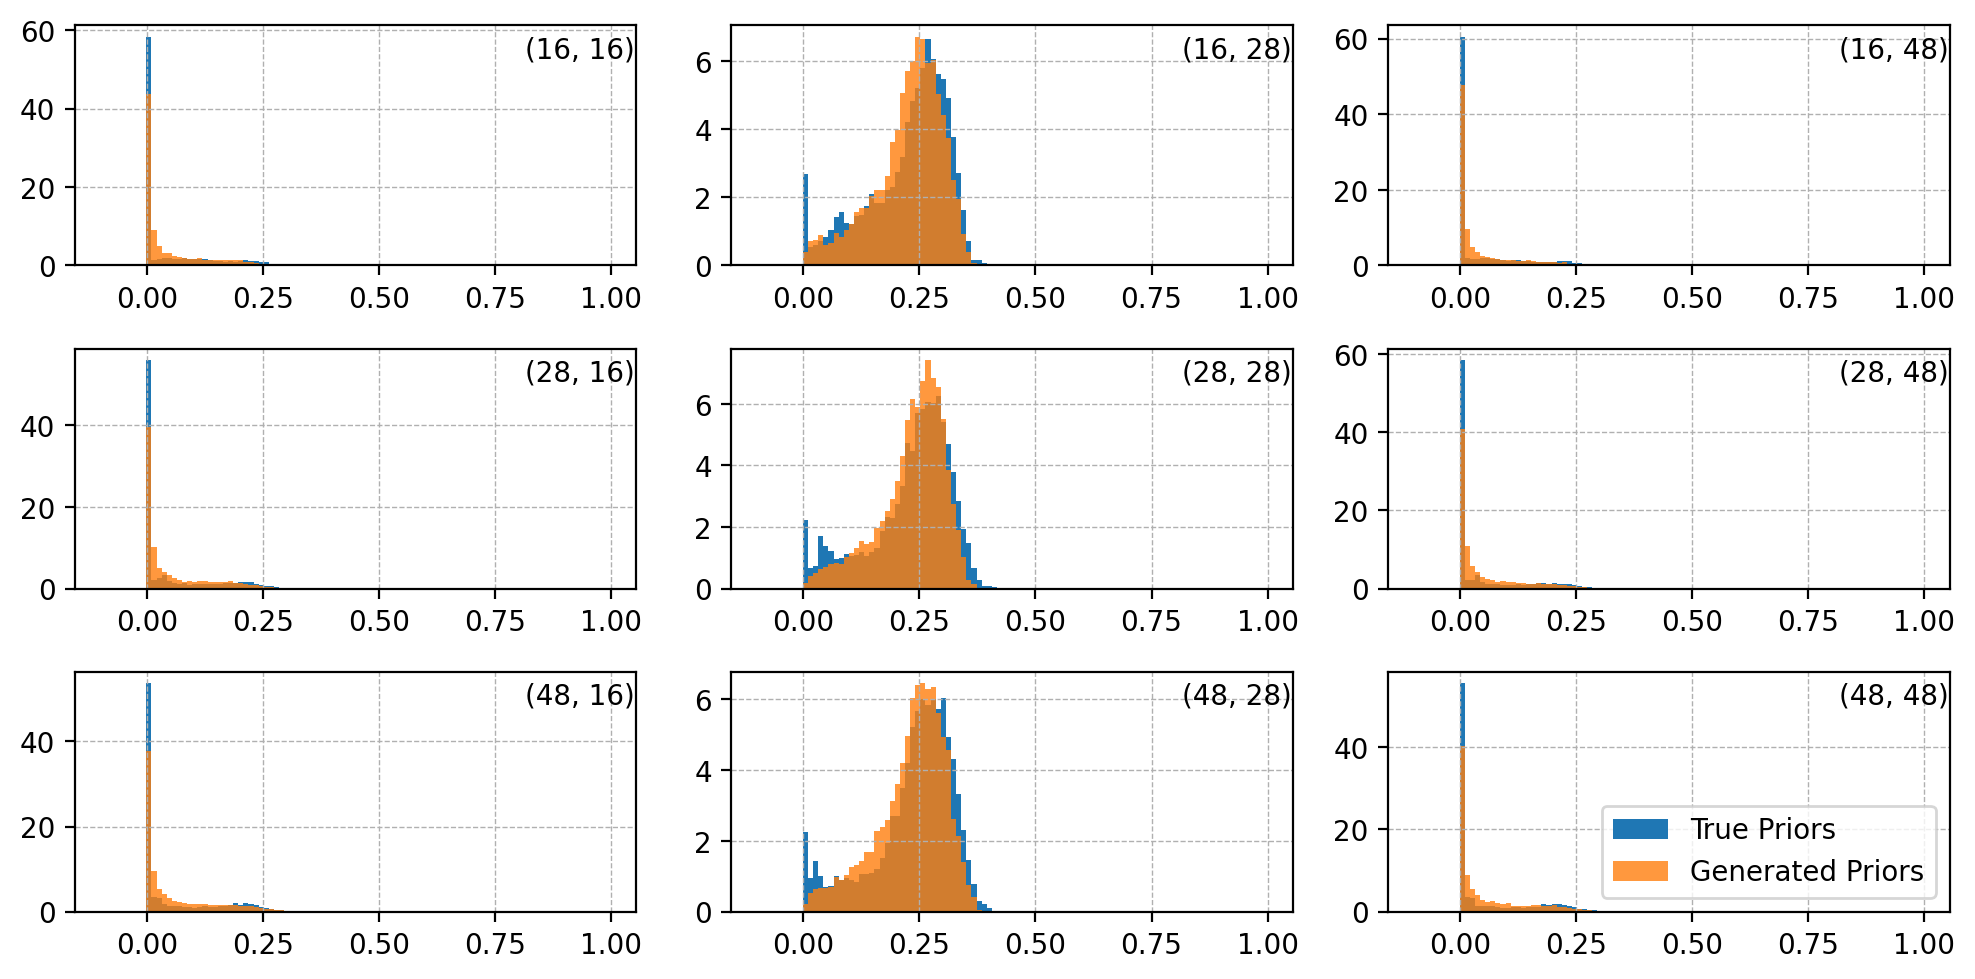

In [21]:
# plot 9 points
points = [[16, 16],
          [16, 28],
          [16, 48],
            [28, 16],
            [28, 28],
            [28, 48],
            [48, 16],
            [48, 28],
            [48, 48]
          ]

# create a 3x3 grid of subplots
plt.figure(figsize=(10, 5), dpi=200)

for i, point in enumerate(points):
    col, row = divmod(i, 3)
    plt.subplot(3, 3, i + 1)
    x, y = point
    plt.hist(train_data[     :, 0, x, y].flatten()                        , bins=100, range=(-0.1, 1), density=True, alpha=1.0, label='True Priors')
    plt.hist(generated[:, 0, x, y].cpu().numpy().squeeze().flatten(), bins=100, range=(-0.1, 1), density=True, alpha=0.8, label='Generated Priors')
    plt.grid(True, which='both', linestyle='--', linewidth=0.5)
    plt.text(0.9, 0.9, f"({x}, {y})", transform=plt.gca().transAxes, ha='center', va='center')

plt.legend()
plt.tight_layout()
plt.show()

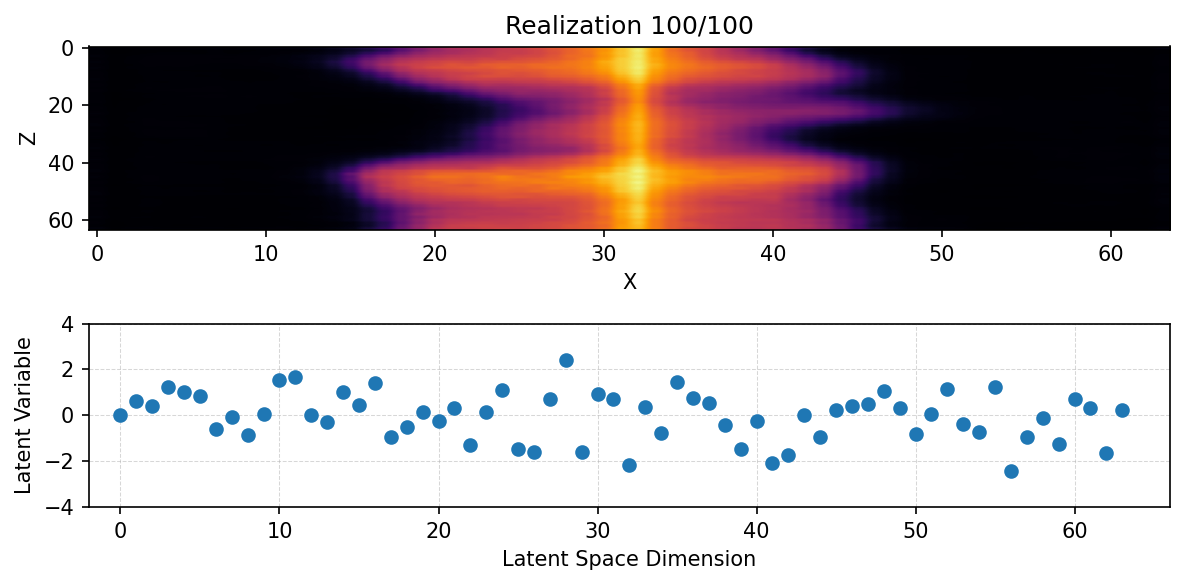

In [22]:
# Setup
n_frames = 100
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 4), dpi=150)

# --- Subplot 1: Image ---
im = ax1.imshow(generated[0].cpu().numpy().squeeze(), cmap='inferno', vmin=0, vmax=0.5, aspect='auto')
ax1.set_title('Generated CO2 Plume')
ax1.set_xlabel('X')
ax1.set_ylabel('Z')

# --- Subplot 2: Latent Space ---
sc = ax2.plot(z[0].cpu().numpy(), marker='o', linestyle='None')[0]
ax2.set_xlim(-2, latent_dim + 2)
ax2.set_ylim(-4, 4)
ax2.grid(True, linestyle='--', linewidth=0.5, alpha=0.5)
ax2.set_xlabel('Latent Space Dimension')
ax2.set_ylabel('Latent Variable')

# --- Update function ---
def update(frame):
    im.set_data(generated[frame].cpu().numpy().squeeze())
    sc.set_ydata(z[frame].cpu().numpy())
    ax1.set_title(f'Realization {frame+1}/{n_frames}')
    return im, sc

# --- Create animation ---
anim = FuncAnimation(fig, update, frames=n_frames, interval=300, blit=False)

# --- Display in notebook or save to file ---
plt.tight_layout()
# To display inline (e.g., in Jupyter), uncomment:
# from IPython.display import HTML
# HTML(anim.to_jshtml())

# To save to file
anim.save(f"figures/prior_generated_vae_latent_dim{latent_dim}_kld_weight{kld_weight}.mp4", writer='ffmpeg', fps=2)
plt.show()